<div style="background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 9 — DATA ANALYST</h1>
<h2 style="margin: auto; padding: 10px 0; color:#fff; text-align: center">Livrable 1 — Analyse des ventes de la librairie Lapage</h2>
<h3 style="margin: auto; padding: 10px 0 20px 0; color:#fff; text-align: center; font-weight: normal;">Demande Annabelle (Marketing) & Sylvain (Direction commerciale)</h3>
</div>

<h1>Contexte de la mission</h1>
<p>La librairie <strong>Lapage</strong>, historiquement présente en magasin physique, a ouvert il y a 2 ans son <strong>site de vente en ligne</strong>. La direction commerciale, menée par Sylvain (nouveau responsable commercial), souhaite aujourd'hui faire le point global sur les indicateurs clés afin de décider de la marche à suivre (offres, prix, ciblage clientèle).</p>

<p>Cette mission se décompose en deux livrables :</p>
<ol>
    <li><strong>Livrable 1 (CE NOTEBOOK)</strong> — Analyse des indicateurs de vente demandée par Annabelle (Responsable Marketing) et Sylvain (Direction commerciale) : chiffre d'affaires, références produits, profils clients.</li>
    <li><strong>Livrable 2 — Analyses statistiques du comportement des clients en ligne demandées par Julie (BI Analyst), afin de comparer avec celui des clients en magasin physique.</li>
</ol>

# Table des matières
* [Partie 0 - Préparation des données](#part0)
    * [0.1 - Import des librairies](#part0_1)
    * [0.2 - Chargement des fichiers](#part0_2)
    * [0.3 - Nettoyage par fichier](#part0_3)
        * [0.3.1 Fichier clients](#part0_3_1)
        * [0.3.2 Fichier produits](#part0_3_2)
        * [0.3.3 Fichier transactions](#part0_3_3)
    * [0.4 - Jointure et vérification finale](#part0_4)
* [Partie 1 - Analyses descriptives (Annabelle / Sylvain)](#part1)
    * [A - Chiffre d'affaires](#part1_A)
    * [B - Références produits](#part1_B)
    * [C - Profils clients](#part1_C)
* [Synthèse exécutive — Analyse des ventes](#synthese)

<div style="background-color: RGB(0,150,250);" >
<a class="anchor" id="part0"><h2 style="margin: auto; padding: 20px; color:#fff; ">Partie 0 - Préparation des données</h2></a>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_1"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.1 - Import des librairies</h3></a>
</div>

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dates
import datetime as dt

# Statistiques
import scipy.stats as st
import statsmodels.api as sm

# Configuration globale des graphiques (cohérence visuelle)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 90
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Librairies importées avec succès")

Librairies importées avec succès


<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_2"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.2 - Chargement des fichiers</h3></a>
</div>

Trois fichiers CSV nous sont fournis par l'entreprise Lapage :
- **`customers.csv`** — base clients (identifiant, genre, année de naissance)
- **`products.csv`** — catalogue produits (identifiant, prix, catégorie)
- **`Transactions.csv`** — historique des transactions en ligne sur environ 2 ans

In [2]:
# Chargement des 3 fichiers sources
clients = pd.read_csv('customers.csv', sep=';')
produits = pd.read_csv('products.csv', sep=';')
transactions = pd.read_csv('Transactions.csv', sep=';')

print(f"Clients      : {clients.shape[0]:>7,} lignes — {clients.shape[1]} colonnes")
print(f"Produits     : {produits.shape[0]:>7,} lignes — {produits.shape[1]} colonnes")
print(f"Transactions : {transactions.shape[0]:>7,} lignes — {transactions.shape[1]} colonnes")

Clients      :   8,621 lignes — 3 colonnes
Produits     :   3,286 lignes — 3 colonnes
Transactions : 1,048,575 lignes — 4 colonnes


C:\Users\oubak\AppData\Local\Temp\ipykernel_3584\476514182.py:4: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('Transactions.csv', sep=';')


In [3]:
# Palette de couleurs cohérente pour tout le notebook
# - part1 : analyses Annabelle/Sylvain (descriptif)
# - part2 : analyses Julie (statistiques)
# - neutral : couleur grise pour les courbes de référence (ex: ligne d'égalité de Lorenz)
PALETTE = {
    'part1':   '#0072C8',   # bleu Lapage
    'part2':   '#10b981',   # vert pour les stats
    'neutral': '#94a3b8',   # gris neutre
}

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_3"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.3 - Nettoyage par fichier</h3></a>
</div>

<p>Pour chaque fichier, on applique la même grille d'analyse qualité :</p>
<ol>
    <li>Aperçu et dimensions</li>
    <li>Types de données</li>
    <li>Valeurs manquantes</li>
    <li>Doublons sur la clé primaire</li>
    <li>Détection d'outliers</li>
</ol>

<h4 style="color: RGB(0,150,250); ">Point d'attention</h4>
<ul>
    <li>Le fichier fourni par OpenClassrooms est annoncé comme déjà nettoyé. On vérifie quand même : la qualité des données conditionne la fiabilité de toute l'analyse qui suivra.</li>
</ul>

<a class="anchor" id="part0_3_1"><h3 style="color: RGB(0,150,250); ">0.3.1 - Fichier clients</h3></a>

In [4]:
# Aperçu
clients.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [5]:
# Création de la colonne 'age' à partir de la date max des transactions
# (plus robuste qu'une valeur figée comme 2023)
# Note : on calcule l'âge par rapport à 2023 car les transactions s'étalent sur 2021-2023
clients['age'] = 2023 - clients['birth']
clients = clients.drop(columns='birth')
clients.head()

,client_id,sex,age
0,c_4410,f,56
1,c_7839,f,48
2,c_1699,f,39
3,c_5961,f,61
4,c_5320,m,80


<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>On dispose de l'âge des clients (calculé à partir de l'année de naissance), du genre et de l'identifiant.</li>
    <li>On dénombre quelques milliers de clients.</li>
</ul>

<h4 style="color: RGB(0,150,250); ">Types de données</h4>

In [6]:
clients.dtypes

client_id    object
sex          object
age           int64
dtype: object

<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Les types sont cohérents : <code>object</code> pour les identifiants et le genre, <code>int</code> pour l'âge.</li>
</ul>

<h4 style="color: RGB(0,150,250); ">Valeurs manquantes</h4>

In [7]:
nb_na = clients.isnull().sum()
nb_na[nb_na > 0] if (nb_na > 0).any() else print("Aucune valeur manquante dans la table clients")

Aucune valeur manquante dans la table clients


<h4 style="color: RGB(0,150,250); ">Doublons sur la clé primaire <code>client_id</code></h4>

In [8]:
doublons = clients.loc[clients['client_id'].duplicated(keep=False), :]
if doublons.empty:
    print("Aucun doublon sur client_id")
else:
    display(doublons)

Aucun doublon sur client_id


<h4 style="color: RGB(0,150,250); ">Détection d'outliers (statistiques descriptives)</h4>

In [9]:
clients.describe()

,age
count,8621.000000
mean,44.724394
std,16.917958
min,19.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,94.000000


<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Quelques clients très âgés sont présents, mais sans valeur aberrante manifeste (pas de 200 ans, etc.).</li>
    <li>On garde la totalité de l'échantillon pour l'instant.</li>
</ul>

<a class="anchor" id="part0_3_2"><h3 style="color: RGB(0,150,250); ">0.3.2 - Fichier produits</h3></a>

In [10]:
produits.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [11]:
print(f"Le catalogue comporte {produits.shape[0]:,} articles")
print(f"Réparti(s) sur {produits['categ'].nunique()} catégories : {sorted(produits['categ'].unique())}")

Le catalogue comporte 3,286 articles
Réparti(s) sur 3 catégories : [np.int64(0), np.int64(1), np.int64(2)]


<h4 style="color: RGB(0,150,250); ">Types de données</h4>

In [12]:
produits.dtypes

id_prod     object
price      float64
categ        int64
dtype: object

<h4 style="color: RGB(0,150,250); ">Valeurs manquantes</h4>

In [13]:
nb_na = produits.isnull().sum()
nb_na[nb_na > 0] if (nb_na > 0).any() else print("Aucune valeur manquante dans la table produits")

Aucune valeur manquante dans la table produits


<h4 style="color: RGB(0,150,250); ">Doublons sur <code>id_prod</code></h4>

In [14]:
doublons = produits.loc[produits['id_prod'].duplicated(keep=False), :].sort_values('id_prod')
if doublons.empty:
    print("Aucun doublon sur id_prod")
else:
    display(doublons)

Aucun doublon sur id_prod


<h4 style="color: RGB(0,150,250); ">Détection d'outliers</h4>

In [15]:
produits.describe()

,price,categ
count,3286.000000,3286.000000
mean,21.863597,0.370359
std,29.849786,0.615446
min,0.620000,0.000000
25%,6.990000,0.000000
50%,13.075000,0.000000
75%,22.990000,1.000000
max,300.000000,2.000000


<h4 style="color: RGB(0,150,250); ">Point d'attention</h4>
<ul>
    <li>On détecte une très grande différence entre le prix min et le prix max et personnellement je vois que c'est logique parce que les catégories des produits se diffèrent dans une librairie on peut trouver des romans qui coutent chers et des produits qui ne dépassent pas 1€ .</li>
</ul>

<a class="anchor" id="part0_3_3"><h3 style="color: RGB(0,150,250); ">0.3.3 - Fichier transactions</h3></a>

In [16]:
transactions.head()

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [17]:
print(f"Nombre de transactions : {transactions.shape[0]:,}")
print(f"Nombre de colonnes      : {transactions.shape[1]}")

Nombre de transactions : 1,048,575
Nombre de colonnes      : 4


<h4 style="color: RGB(0,150,250); ">Types de données</h4>

In [18]:
transactions.dtypes

id_prod       object
date          object
session_id    object
client_id     object
dtype: object

<h4 style="color: RGB(0,150,250); ">Point d'attention</h4>
<ul>
    <li>La colonne <code>date</code> est en <code>object</code> au lieu de <code>datetime</code>.</li>
</ul>

<h4 style="color: RGB(0,150,250); ">Action correctrice</h4>
<ul>
    <li>Conversion de la colonne <code>date</code> au format datetime.</li>
    <li>Le fichier source contient ~361 000 lignes complètement vides (artefact d'un passage par Excel, qui complète jusqu'à sa limite de 1 048 576 lignes). On les supprime avec dropna(how='all').</li>
</ul>

In [19]:
# Suppression des lignes complètement vides (artefact d'un export Excel)
transactions = transactions.dropna(how='all').copy()

# Conversion de la colonne 'date' en format datetime
transactions['date'] = pd.to_datetime(transactions['date'])

print(f"Transactions : {transactions.shape[0]:,} lignes")

Transactions : 687,534 lignes


In [20]:
# Création de variables temporelles utiles pour l'analyse
transactions['Year']  = transactions['date'].dt.year
transactions['Month'] = transactions['date'].dt.month
transactions['Day']   = transactions['date'].dt.day

# Date sans la composante horaire (utile pour les agrégations journalières)
transactions['date2'] = pd.to_datetime(
    transactions[['Year', 'Month', 'Day']], errors='coerce'
)

# Variable mensuelle (1er du mois) — base pour l'évolution mensuelle du CA
transactions['annee_mois'] = transactions['date'].dt.to_period('M').dt.to_timestamp()

# Nettoyage des colonnes intermédiaires
transactions = transactions.drop(columns=['Year', 'Month', 'Day'])
transactions.head()

,id_prod,date,session_id,client_id,date2,annee_mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021-03-01,2021-03-01
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021-03-01,2021-03-01
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021-03-01,2021-03-01
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021-03-01,2021-03-01
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021-03-01,2021-03-01


<h4 style="color: RGB(0,150,250); ">Valeurs manquantes</h4>

In [21]:
nb_na = transactions.isnull().sum()
nb_na[nb_na > 0] if (nb_na > 0).any() else print("Aucune valeur manquante dans la table transactions")

Aucune valeur manquante dans la table transactions


<h4 style="color: RGB(0,150,250); ">Doublons</h4>

In [22]:
doublons = transactions.loc[
    transactions[['id_prod','date','session_id','client_id']].duplicated(keep=False), :
].sort_values('session_id')
if doublons.empty:
    print("Aucun doublon")
else:
    display(doublons)

Aucun doublon


<h4 style="color: RGB(0,150,250); ">Outliers et amplitude temporelle</h4>

In [23]:
transactions.describe()

,date,date2,annee_mois
count,687534,687534,687534
mean,2022-03-01 21:24:00.618519296,2022-03-01 09:22:26.987930880,2022-02-14 16:12:28.721081600
min,2021-03-01 00:01:07.843138,2021-03-01 00:00:00,2021-03-01 00:00:00
25%,2021-09-10 10:35:20.642323456,2021-09-10 00:00:00,2021-09-01 00:00:00
50%,2022-02-27 06:50:25.400120064,2022-02-27 00:00:00,2022-02-01 00:00:00
75%,2022-08-28 22:16:49.841665536,2022-08-28 00:00:00,2022-08-01 00:00:00
max,2023-02-28 23:58:30.792755,2023-02-28 00:00:00,2023-02-01 00:00:00


<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Les transactions s'étalent sur environ 2 ans, conforme à ce qui est annoncé dans le brief (site ouvert il y a 2 ans).</li>
</ul>

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_4"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.4 - Jointure des tables et vérification finale</h3></a>
</div>

On joint les 3 tables pour obtenir une table unique `data` contenant, pour chaque transaction, le prix et la catégorie du produit ainsi que les caractéristiques du client (genre, âge).

Schéma de jointure : `transactions ; produits` (sur `id_prod`) puis `clients` (sur `client_id`).

In [24]:
# Double jointure
data = pd.merge(transactions, produits, on='id_prod', how='left')
data = pd.merge(data, clients, on='client_id', how='left')

print(f"Table consolidée : {data.shape[0]:,} achats × {data.shape[1]} colonnes")
data.head()

Table consolidée : 687,534 achats × 10 colonnes


,id_prod,date,session_id,client_id,date2,annee_mois,price,categ,sex,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021-03-01,2021-03-01,11.99,0,f,56
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021-03-01,2021-03-01,19.37,0,m,63
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021-03-01,2021-03-01,4.50,0,m,35
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021-03-01,2021-03-01,6.55,0,f,34
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021-03-01,2021-03-01,16.49,0,f,67


<h4 style="color: RGB(0,150,250); ">Vérification post-jointure : valeurs manquantes</h4>

In [25]:
nb_na = data.isnull().sum()
nb_na[nb_na > 0]

Series([], dtype: int64)

<h4 style="color: RGB(0,150,250); ">Conclusion</h4>
<ul>
    <li>La phase de nettoyage est terminée. On dispose maintenant d'une table consolidée <code>data</code> propre, prête pour l'analyse.</li>
</ul>

<div style="background-color: RGB(0,150,250);" >
<a class="anchor" id="part1"><h2 style="margin: auto; padding: 20px; color:#fff; ">Partie 1 - Analyses descriptives (demande Annabelle / Sylvain)</h2></a>
</div>

<h4>Objectif</h4>
<p>Dresser un état des lieux complet de l'activité de Lapage pour permettre à Sylvain et son CODIR de prendre des décisions éclairées. On structure l'analyse en 3 axes :</p>
<ol>
    <li><strong>Chiffre d'affaires</strong> — santé financière et tendances</li>
    <li><strong>Références produits</strong> — performance du catalogue</li>
    <li><strong>Profils clients</strong> — répartition et concentration</li>
</ol>

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part1_A"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">A - Chiffre d'affaires</h3></a>
</div>

<a class="anchor" id="part1_A_1"><h3 style="color: RGB(0,150,250); ">A.1 - Chiffre d'affaires total sur la période</h3></a>

In [26]:
# CA total sur l'ensemble de la période
ca_total = data['price'].sum()
print(f"Chiffre d'affaires total : {ca_total:,.2f} €".replace(",", " "))

Chiffre d'affaires total : 12 027 663.10 €


<a class="anchor" id="part1_A_2"><h3 style="color: RGB(0,150,250); ">A.2 - Évolution mensuelle du CA + moyenne mobile</h3></a>

On agrège le CA par mois et on calcule une **moyenne mobile sur 3 mois** pour lisser la courbe et mettre en évidence la tendance de fond.

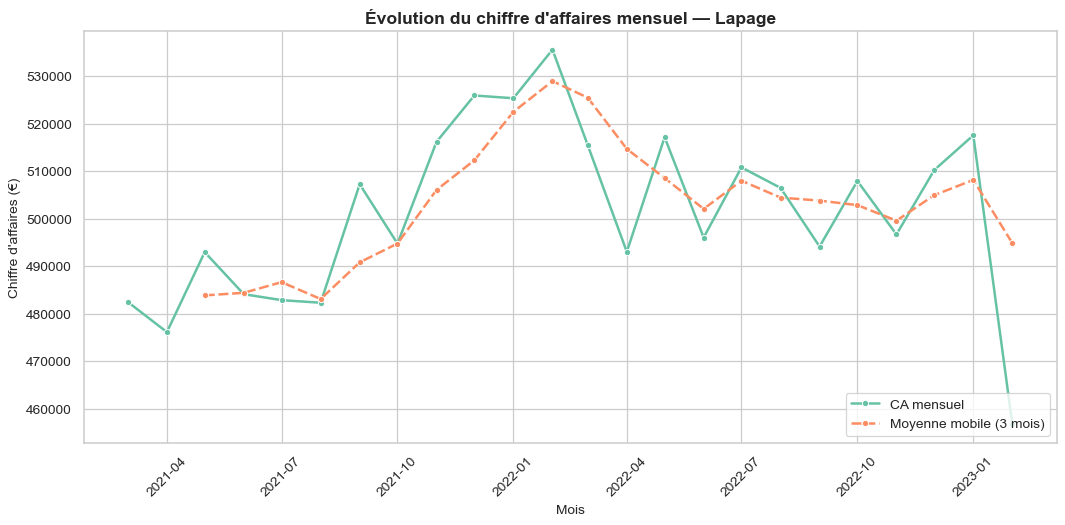

In [27]:
# CA mensuel
ca_mensuel = (data[['annee_mois', 'price']]
              .groupby('annee_mois').sum()
              .sort_index()
              .reset_index())

# Moyenne mobile sur 3 mois
ca_mensuel['Moyenne_mobile'] = ca_mensuel['price'].rolling(3).mean()

# Mise en forme pour le graphique
ca_mensuel_plot = ca_mensuel.set_index('annee_mois')[['price', 'Moyenne_mobile']]
ca_mensuel_plot.columns = ['CA mensuel', 'Moyenne mobile (3 mois)']

# Graphique
plt.figure(figsize=(12, 6))
sns.lineplot(data=ca_mensuel_plot, linewidth=2, marker='o', markersize=5)
plt.title("Évolution du chiffre d'affaires mensuel — Lapage", fontsize=14, fontweight='bold')
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(rotation=45)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

<h4 style="color: RGB(0,150,250); ">Interpretation</h4>
<ul>
    <li>Le chiffre d’affaires montre une tendance globale à la hausse entre 2021 et début 2022, avec un pic autour de 535 k€. La moyenne mobile confirme cette croissance avant un ralentissement et une stabilisation autour de 500 k€ en 2022. La baisse observée sur le dernier mois s’explique par la période incomplète en fin de jeu de données..</li>
</ul>

<a class="anchor" id="part1_A_3"><h3 style="color: RGB(0,150,250); ">A.3 - Comparaison du CA sur les 2 ans 2021-2022 et 2022-2023</h3></a>

Pour mesurer la **croissance annuelle**, on compare le CA cumulé sur 12 mois glissants entre la première et la deuxième année.

C:\Users\oubak\AppData\Local\Temp\ipykernel_3584\3840571725.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


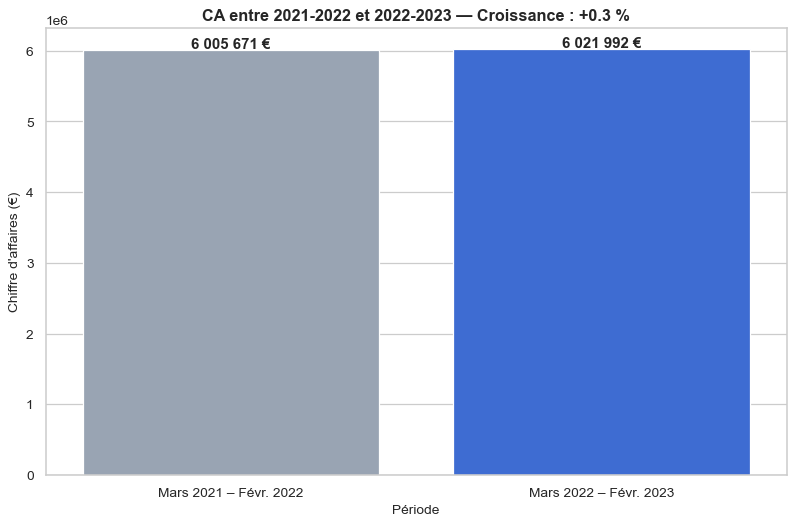


 Croissance entre la 1re et la 2e année : +0.3 %


In [28]:
# Somme mobile sur 12 mois
ca_douze_mois = ca_mensuel.set_index('annee_mois')['price'].rolling(12).sum()

# On extrait le 12e mois et le dernier
ca_compar = pd.DataFrame({
    'Période'           : ['Mars 2021 – Févr. 2022', 'Mars 2022 – Févr. 2023'],
    "Chiffre d'affaires": [ca_douze_mois.iloc[11], ca_douze_mois.iloc[-1]]
})

# Croissance en %
croissance = 100 * (ca_compar["Chiffre d'affaires"].iloc[1] / ca_compar["Chiffre d'affaires"].iloc[0] - 1)

# Graphique
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=ca_compar,
    x='Période',
    y="Chiffre d'affaires",
    palette=['#94a3b8', '#2563eb']
)
plt.xlabel('Période')
plt.ylabel("Chiffre d'affaires (€)")
plt.title(f"CA entre 2021-2022 et 2022-2023 — Croissance : {croissance:+.1f} %", 
          fontsize=13, fontweight='bold')

# Annotation des valeurs
for i, v in enumerate(ca_compar["Chiffre d'affaires"]):
    ax.text(i, v + 30000, f'{v:,.0f} €'.replace(',', ' '), 
            ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Croissance entre la 1re et la 2e année : {croissance:+.1f} %")

<h4 style="color: RGB(0,150,250); ">Conclusion</h4>
<ul>
    <li>Le chiffre d'affaires augmente sensiblement entre la 1re et la 2e année du site en ligne.</li>
    <li>Bon signal pour la pérennité du canal e-commerce.</li>
</ul>

<a class="anchor" id="part1_A_4"><h3 style="color: RGB(0,150,250); ">A.4 - Répartition du CA par catégorie</h3></a>

C:\Users\oubak\AppData\Local\Temp\ipykernel_3584\2348895426.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ca_categ, x='categ', y='chiffre_affaires',


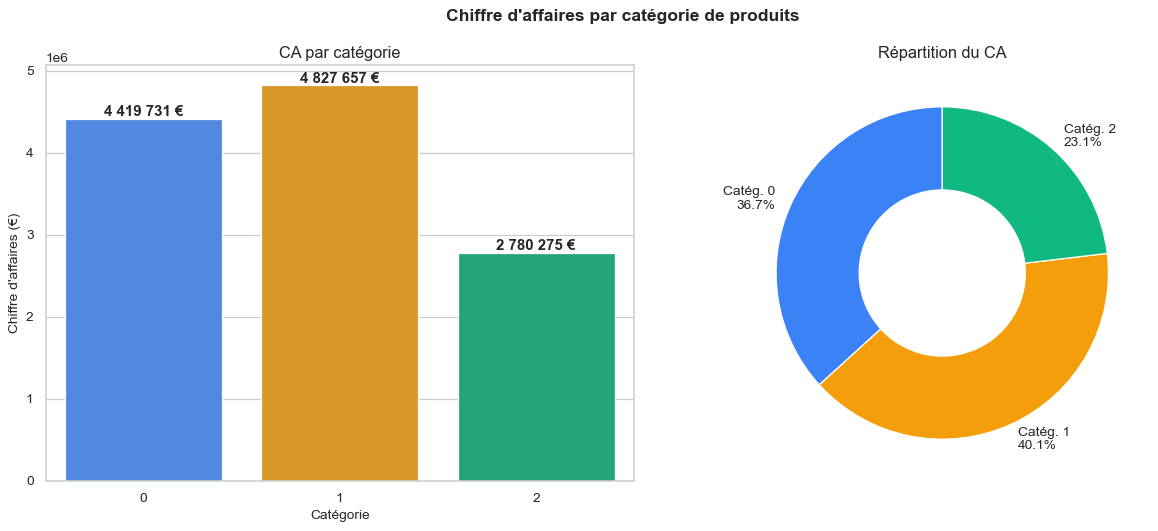

,categ,chiffre_affaires,part_pct
0,0,4419730.97,36.746382
1,1,4827657.11,40.137948
2,2,2780275.02,23.115671


In [29]:
# CA par catégorie (correction : on agrège uniquement 'price')
ca_categ = (data.groupby('categ')['price'].sum()
            .reset_index()
            .rename(columns={'price': 'chiffre_affaires'}))

# Part en pourcentage
ca_categ['part_pct'] = 100 * ca_categ['chiffre_affaires'] / ca_categ['chiffre_affaires'].sum()

# Graphique double : barres + camembert
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barres
sns.barplot(data=ca_categ, x='categ', y='chiffre_affaires', 
            palette=['#3b82f6', '#f59e0b', '#10b981'], ax=axes[0])
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel("Chiffre d'affaires (€)")
axes[0].set_title("CA par catégorie")
for i, v in enumerate(ca_categ['chiffre_affaires']):
    axes[0].text(i, v + 30000, f'{v:,.0f} €'.replace(',', ' '), 
                 ha='center', fontweight='bold')

# Camembert
axes[1].pie(ca_categ['chiffre_affaires'], 
            labels=[f"Catég. {c}\n{p:.1f}%" for c, p in zip(ca_categ['categ'], ca_categ['part_pct'])],
            colors=['#3b82f6', '#f59e0b', '#10b981'],
            autopct='', startangle=90, wedgeprops=dict(width=0.5, edgecolor='white'))
axes[1].set_title("Répartition du CA")

plt.suptitle("Chiffre d'affaires par catégorie de produits", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(ca_categ)

Le CA est porté par deux catégories principales (0 et 1) qui génèrent environ 8.2 millions d'euros. La catégorie 1 légèrement devant (+ 408k€ par rapport à la catég. 0). La catégorie 2 est significativement en retrait, ce qui soulève la question : est-ce une catégorie moins rentable, moins demandée, ou sous-exploitée ?

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part1_A_5"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">A.5 - Évolution de l'activité (transactions, produits, clients)</h3></a>
</div>

Pour compléter l'analyse du chiffre d'affaires, on regarde l'évolution mensuelle de **3 indicateurs volumiques** qui aident à interpréter les variations de CA :
- nombre de **transactions** (commandes)
- nombre de **produits vendus**
- nombre de **clients uniques** par mois

<h4 style="color: RGB(0,150,250); ">A.5.1 — Nombre de transactions par mois</h4>

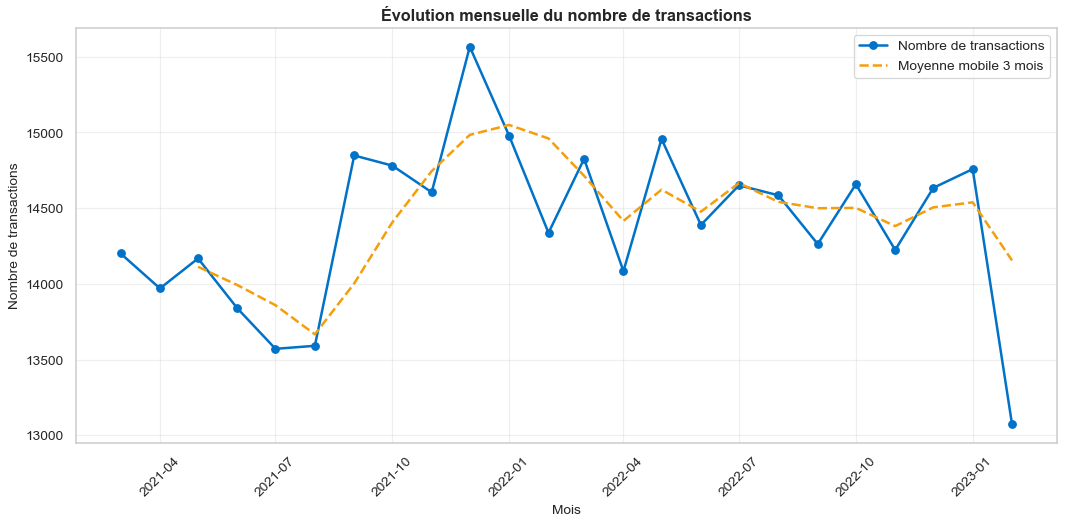

Total de transactions sur 2 ans : 345,505
Moyenne mensuelle               : 14,398
Min mensuel                     : 13,073
Max mensuel                     : 15,566

--- Moyenne mobile 3 mois ---
Min (MM)                        : 13,667
Max (MM)                        : 15,050


In [30]:
# Évolution du nombre de transactions (= commandes) par mois
# On utilise .nunique() sur session_id pour compter le nombre de COMMANDES distinctes
nb_transactions_mois = (
    data.groupby('annee_mois')['session_id']
        .nunique()
        .reset_index(name='nb_transactions')
        .sort_values('annee_mois')
)

# ✨ NOUVEAU : Calculer la moyenne mobile 3 mois
nb_transactions_mois['MM_3mois'] = nb_transactions_mois['nb_transactions'].rolling(3).mean()

# Visualisation
plt.figure(figsize=(12, 6))

# Courbe 1 : nombre de transactions (brut)
plt.plot(nb_transactions_mois['annee_mois'],
         nb_transactions_mois['nb_transactions'],
         marker='o', linewidth=2, color=PALETTE['part1'], 
         label='Nombre de transactions')

# ✨ Courbe 2 : moyenne mobile (orange, traits discontinus)
plt.plot(nb_transactions_mois['annee_mois'],
         nb_transactions_mois['MM_3mois'],
         linewidth=2, color='#f59e0b', linestyle='--',
         label='Moyenne mobile 3 mois')

plt.title("Évolution mensuelle du nombre de transactions", fontsize=13, fontweight='bold')
plt.xlabel("Mois")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques résumées (utile pour la synthèse orale)
print(f"Total de transactions sur 2 ans : {data['session_id'].nunique():,}")
print(f"Moyenne mensuelle               : {nb_transactions_mois['nb_transactions'].mean():,.0f}")
print(f"Min mensuel                     : {nb_transactions_mois['nb_transactions'].min():,}")
print(f"Max mensuel                     : {nb_transactions_mois['nb_transactions'].max():,}")
print(f"\n--- Moyenne mobile 3 mois ---")
print(f"Min (MM)                        : {nb_transactions_mois['MM_3mois'].min():,.0f}")
print(f"Max (MM)                        : {nb_transactions_mois['MM_3mois'].max():,.0f}")

<h4 style="color: RGB(0,150,250); ">A.5.2 — Nombre de produits vendus par mois</h4>

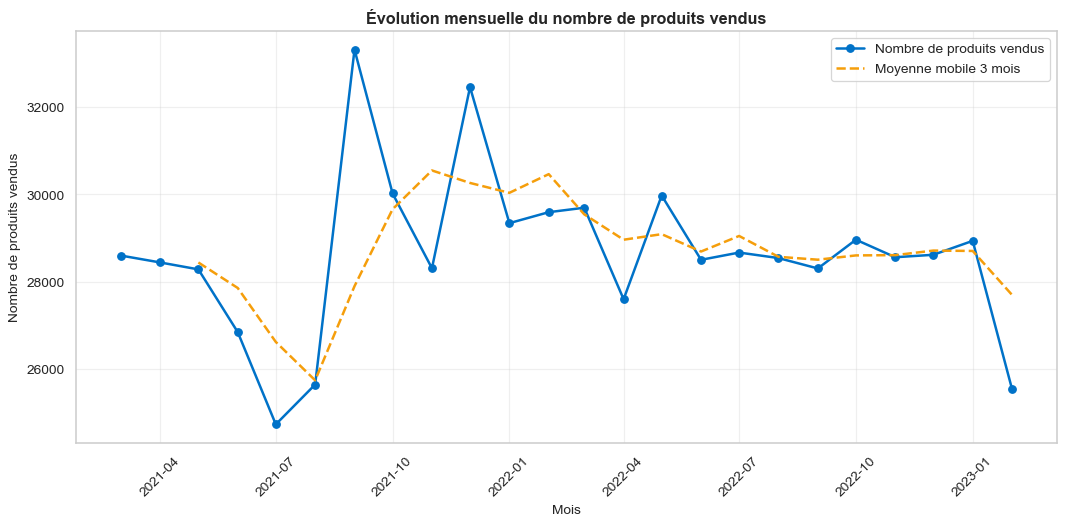

Total de produits vendus sur 2 ans : 687,534
Moyenne mensuelle                  : 28,647
Min mensuel                        : 24,738
Max mensuel                        : 33,314

--- Moyenne mobile 3 mois ---
Min (MM)                           : 25,746
Max (MM)                           : 30,549


In [31]:
# Nombre de produits vendus par mois
# Chaque ligne de 'data' représente 1 produit acheté → on compte les lignes par mois
nb_produits_mois = (
    data.groupby('annee_mois')
        .size()
        .reset_index(name='nb_produits')
        .sort_values('annee_mois')
)

# ✨ NOUVEAU : Calculer la moyenne mobile 3 mois
nb_produits_mois['MM_3mois'] = nb_produits_mois['nb_produits'].rolling(3).mean()

# Visualisation
plt.figure(figsize=(12, 6))

# Courbe 1 : nombre de produits (brut)
plt.plot(nb_produits_mois['annee_mois'],
         nb_produits_mois['nb_produits'],
         marker='o', linewidth=2, color=PALETTE['part1'],
         label='Nombre de produits vendus')

# ✨ Courbe 2 : moyenne mobile (orange, traits discontinus)
plt.plot(nb_produits_mois['annee_mois'],
         nb_produits_mois['MM_3mois'],
         linewidth=2, color='#f59e0b', linestyle='--',
         label='Moyenne mobile 3 mois')

plt.title("Évolution mensuelle du nombre de produits vendus", fontsize=13, fontweight='bold')
plt.xlabel("Mois")
plt.ylabel("Nombre de produits vendus")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques résumées
print(f"Total de produits vendus sur 2 ans : {len(data):,}")
print(f"Moyenne mensuelle                  : {nb_produits_mois['nb_produits'].mean():,.0f}")
print(f"Min mensuel                        : {nb_produits_mois['nb_produits'].min():,}")
print(f"Max mensuel                        : {nb_produits_mois['nb_produits'].max():,}")
print(f"\n--- Moyenne mobile 3 mois ---")
print(f"Min (MM)                           : {nb_produits_mois['MM_3mois'].min():,.0f}")
print(f"Max (MM)                           : {nb_produits_mois['MM_3mois'].max():,.0f}")

<h4 style="color: RGB(0,150,250); ">A.5.3 — Nombre de clients uniques par mois</h4>

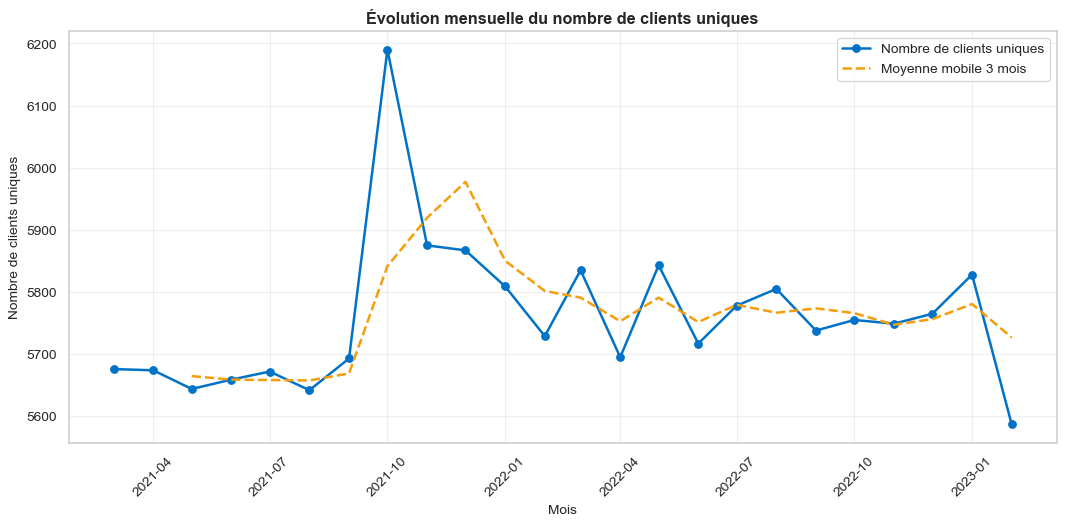

Nombre total de clients distincts sur 2 ans : 8,600
Moyenne mensuelle de clients uniques       : 5,759
Min mensuel                                : 5,587
Max mensuel                                : 6,190

--- Moyenne mobile 3 mois ---
Min (MM)                                   : 5,658
Max (MM)                                   : 5,977


In [32]:
# Nombre de clients uniques par mois
# On utilise .nunique() pour ne compter chaque client qu'UNE SEULE FOIS par mois,
# même s'il a passé plusieurs commandes
nb_clients_mois = (
    data.groupby('annee_mois')['client_id']
        .nunique()
        .reset_index(name='nb_clients_uniques')
        .sort_values('annee_mois')
)

# ✨ NOUVEAU : Calculer la moyenne mobile 3 mois
nb_clients_mois['MM_3mois'] = nb_clients_mois['nb_clients_uniques'].rolling(3).mean()

# Visualisation
plt.figure(figsize=(12, 6))

# Courbe 1 : nombre de clients uniques (brut)
plt.plot(nb_clients_mois['annee_mois'],
         nb_clients_mois['nb_clients_uniques'],
         marker='o', linewidth=2, color=PALETTE['part1'],
         label='Nombre de clients uniques')

# ✨ Courbe 2 : moyenne mobile (orange, traits discontinus)
plt.plot(nb_clients_mois['annee_mois'],
         nb_clients_mois['MM_3mois'],
         linewidth=2, color='#f59e0b', linestyle='--',
         label='Moyenne mobile 3 mois')

plt.title("Évolution mensuelle du nombre de clients uniques", fontsize=13, fontweight='bold')
plt.xlabel("Mois")
plt.ylabel("Nombre de clients uniques")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques résumées
print(f"Nombre total de clients distincts sur 2 ans : {data['client_id'].nunique():,}")
print(f"Moyenne mensuelle de clients uniques       : {nb_clients_mois['nb_clients_uniques'].mean():,.0f}")
print(f"Min mensuel                                : {nb_clients_mois['nb_clients_uniques'].min():,}")
print(f"Max mensuel                                : {nb_clients_mois['nb_clients_uniques'].max():,}")
print(f"\n--- Moyenne mobile 3 mois ---")
print(f"Min (MM)                                   : {nb_clients_mois['MM_3mois'].min():,.0f}")
print(f"Max (MM)                                   : {nb_clients_mois['MM_3mois'].max():,.0f}")

## Synthèse - Activité Lapage (avril 2021 - janvier 2023)

**Transactions** : Croissance jusqu'à janvier 2022 (pic 15 600), puis déclin régulier (-16%) jusqu'janvier 2023. La moyenne mobile confirme une **tendance baissière structurelle**, pas une simple saisonnalité.

**Produits vendus** : Baisse de -20% (bien plus importante que les transactions -16%), révélant que le **panier moyen par client diminue**. Les clients qui reviennent achètent moins.

**Clients uniques** : Perte de 10% de la base clients (6 200 → 5 600). La courbe montre une **declin graduel** depuis octobre 2021, signe d'un **problème de fidélité client**.

**Points clés** : (1) Pic janvier 2022, puis déclin continu. (2) Trois indicateurs baissent ensemble = problème structurel. (3) Panier moyen en baisse (-11%) = clients moins dépensiers. (4) Perte de fidélité visible.

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part1_B"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">B - Références produits</h3></a>
</div>

In [33]:
# Construction d'un dataframe agrégé par référence
data_references = data['id_prod'].value_counts().reset_index()
data_references.columns = ['id_prod', 'nb_ventes']

# Jointure avec le catalogue pour récupérer prix et catégorie
data_references = pd.merge(
    data_references, 
    produits[['categ', 'id_prod', 'price']], 
    on='id_prod', how='left'
)

# CA par référence
data_references['Chiffre_affaires'] = data_references['nb_ventes'] * data_references['price']

print(f"Nombre de références actives : {len(data_references):,}")
data_references.head()

Nombre de références actives : 3,265


,id_prod,nb_ventes,categ,price,Chiffre_affaires
0,1_369,2340,1,23.99,56136.60
1,1_417,2269,1,20.99,47626.31
2,1_414,2246,1,23.83,53522.18
3,1_498,2202,1,23.37,51460.74
4,1_425,2163,1,16.99,36749.37


<a class="anchor" id="part1_B_1"><h3 style="color: RGB(0,150,250); ">B.1 - Répartition des références par catégorie</h3></a>

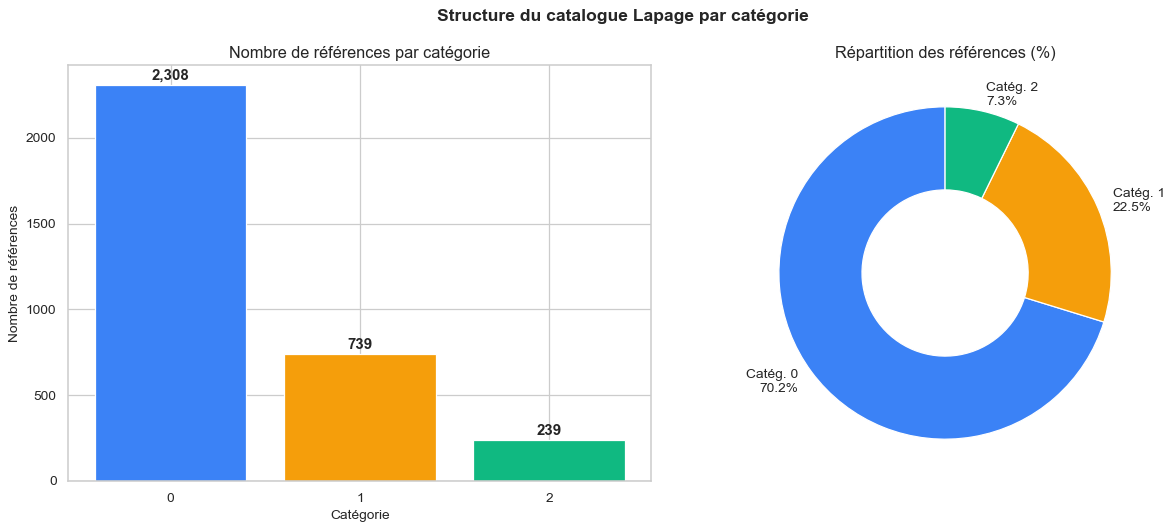

,categ,nb_references,pct
0,0,2308,70.237371
1,1,739,22.489349
2,2,239,7.273281


In [34]:
# Répartition des références du catalogue par catégorie
# On utilise la table 'produits' (le catalogue) et NON 'data' (les ventes)
ref_par_categorie = (
    produits.groupby('categ')
            .size()
            .reset_index(name='nb_references')
)

# Calcul du pourcentage de chaque catégorie dans le catalogue
ref_par_categorie['pct'] = 100 * ref_par_categorie['nb_references'] / ref_par_categorie['nb_references'].sum()

# Visualisation : barres + camembert (pour la cohérence avec A.5)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#3b82f6', '#f59e0b', '#10b981']

# Graphique 1 : barres
axes[0].bar(ref_par_categorie['categ'].astype(str),
            ref_par_categorie['nb_references'],
            color=colors)
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre de références')
axes[0].set_title('Nombre de références par catégorie')
for i, n in enumerate(ref_par_categorie['nb_references']):
    axes[0].text(i, n + 30, f'{n:,}', ha='center', fontweight='bold')

# Graphique 2 : camembert (pourcentages)
axes[1].pie(ref_par_categorie['nb_references'],
            labels=[f"Catég. {c}\n{p:.1f}%" 
                    for c, p in zip(ref_par_categorie['categ'], ref_par_categorie['pct'])],
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='white'))
axes[1].set_title('Répartition des références (%)')

plt.suptitle('Structure du catalogue Lapage par catégorie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(ref_par_categorie)

<a class="anchor" id="part1_B_2"><h3 style="color: RGB(0,150,250); ">B.2 - Prix moyen par catégorie</h3></a>

,Prix moyen,Prix médian,Prix min,Prix max
categ,,,,
0,11.71,10.30,0.62,40.99
1,25.50,22.99,2.00,80.99
2,107.64,101.25,30.99,300.00


C:\Users\oubak\AppData\Local\Temp\ipykernel_3584\1535058792.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_references, x='categ', y='price',


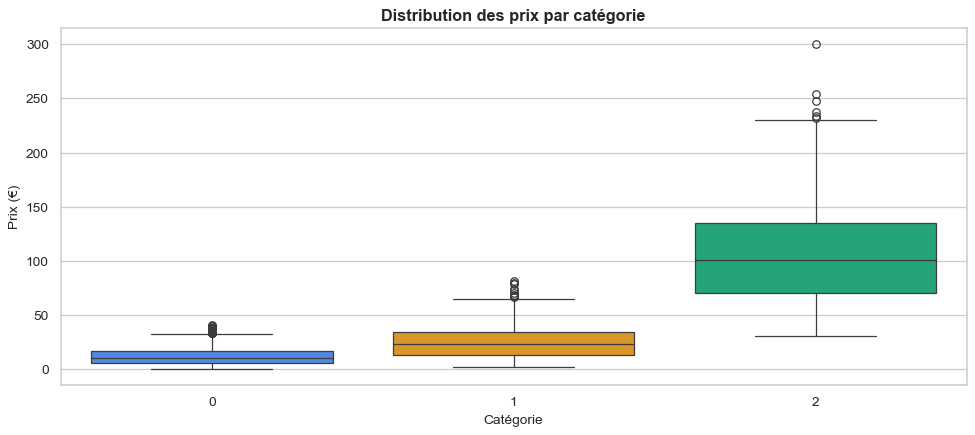

In [35]:
# Prix moyen par catégorie
prix_moyen = data_references.groupby('categ')['price'].agg(['mean', 'median', 'min', 'max']).round(2)
prix_moyen.columns = ['Prix moyen', 'Prix médian', 'Prix min', 'Prix max']
display(prix_moyen)

# Visualisation : boxplot
plt.figure(figsize=(11, 5))
sns.boxplot(data=data_references, x='categ', y='price', 
            palette=['#3b82f6', '#f59e0b', '#10b981'])
plt.xlabel('Catégorie')
plt.ylabel('Prix (€)')
plt.title('Distribution des prix par catégorie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution des prix par catégorie

**Catégorie 0** (Bleu) : Prix très accessibles, médiane ~10€, gamme 0-35€. Entrée de gamme, clients petits budgets.

**Catégorie 1** (Orange) : Milieu de gamme, médiane ~20€, gamme 0-80€. Diversifiée avec mix de produits accessibles et premium.

**Catégorie 2** (Vert) : Haut de gamme, médiane ~100€, gamme 30-300€. Livres premium (beaux-livres, éditions limitées, d'art).

**Insight clé** : Catégorie 2 coûte 5-10x plus cher mais ne représente que 23% du CA (vs 36.7% pour catég. 0). Potentiel énorme sur les produits premium mais volatilité forte. **Hypothèse** : la baisse du panier moyen observée précédemment pourrait être due à une **désaffection des achats haut de gamme** (catégorie 2).

<a class="anchor" id="part1_B_3"><h3 style="color: RGB(0,150,250); ">B.3 - Top 10 des références</h3></a>

In [36]:
print('Top 10 des références par chiffre d\'affaires')
display(data_references.sort_values('Chiffre_affaires', ascending=False).head(10))

print('\nTop 10 des références par nombre de ventes')
display(data_references.sort_values('nb_ventes', ascending=False).head(10))

Top 10 des références par chiffre d'affaires


,id_prod,nb_ventes,categ,price,Chiffre_affaires
341,2_159,650,2,145.99,94893.50
151,2_135,1005,2,68.99,69334.95
169,2_112,968,2,67.57,65407.76
139,2_102,1027,2,59.14,60736.78
242,2_209,814,2,69.99,56971.86
12,1_395,1953,1,28.99,56617.47
0,1_369,2340,1,23.99,56136.60
212,2_110,865,2,62.25,53846.25
19,1_383,1857,1,28.99,53834.43
2,1_414,2246,1,23.83,53522.18



Top 10 des références par nombre de ventes


,id_prod,nb_ventes,categ,price,Chiffre_affaires
0,1_369,2340,1,23.99,56136.60
1,1_417,2269,1,20.99,47626.31
2,1_414,2246,1,23.83,53522.18
3,1_498,2202,1,23.37,51460.74
4,1_425,2163,1,16.99,36749.37
5,1_403,2040,1,17.99,36699.60
6,1_413,2036,1,17.99,36627.64
7,1_412,2014,1,16.65,33533.10
8,1_406,2003,1,24.81,49694.43
9,1_407,2001,1,15.99,31995.99


<h4 style="color: RGB(0,150,250); ">Insight stratégique</h4>
<ul>
    <li>On observe une dissociation intéressante entre CA et volume :
        <ul>
            <li>Les tops en CA sont dominés par la catégorie 2 et après vient la catégorie 1 (effet prix élevé).</li>
            <li>Les tops en volume sont dominés par la catégorie 1 (effet best-sellers populaires).</li>
        </ul>
</ul>

<a class="anchor" id="part1_B_4"><h3 style="color: RGB(0,150,250); ">B.4 - Flop 10 des références</h3></a>

In [37]:
print('Flop 10 des références par chiffre d\'affaires')
display(data_references.sort_values('Chiffre_affaires', ascending=True).head(10))

print('\nFlop 10 des références par nombre de ventes')
display(data_references.sort_values('nb_ventes', ascending=True).head(10))

Flop 10 des références par chiffre d'affaires


,id_prod,nb_ventes,categ,price,Chiffre_affaires
3250,0_1539,1,0,0.99,0.99
3255,0_1284,1,0,1.38,1.38
3229,0_1653,2,0,0.99,1.98
3254,0_541,1,0,1.99,1.99
3252,0_1601,1,0,1.99,1.99
3247,0_807,1,0,1.99,1.99
3253,0_1728,1,0,2.27,2.27
3256,0_1498,1,0,2.48,2.48
3223,0_898,2,0,1.27,2.54
3227,0_1840,2,0,1.28,2.56



Flop 10 des références par nombre de ventes


,id_prod,nb_ventes,categ,price,Chiffre_affaires
3264,0_1633,1,0,24.99,24.99
3251,2_98,1,2,149.74,149.74
3252,0_1601,1,0,1.99,1.99
3253,0_1728,1,0,2.27,2.27
3254,0_541,1,0,1.99,1.99
3255,0_1284,1,0,1.38,1.38
3256,0_1498,1,0,2.48,2.48
3257,2_81,1,2,86.99,86.99
3258,0_549,1,0,2.99,2.99
3259,0_1151,1,0,2.99,2.99


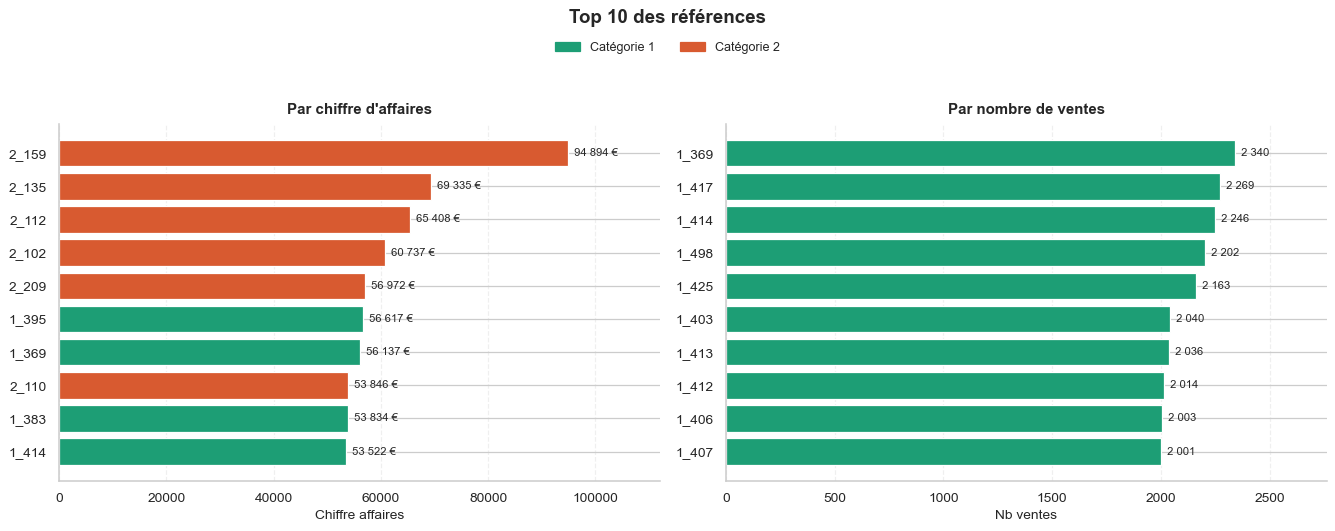

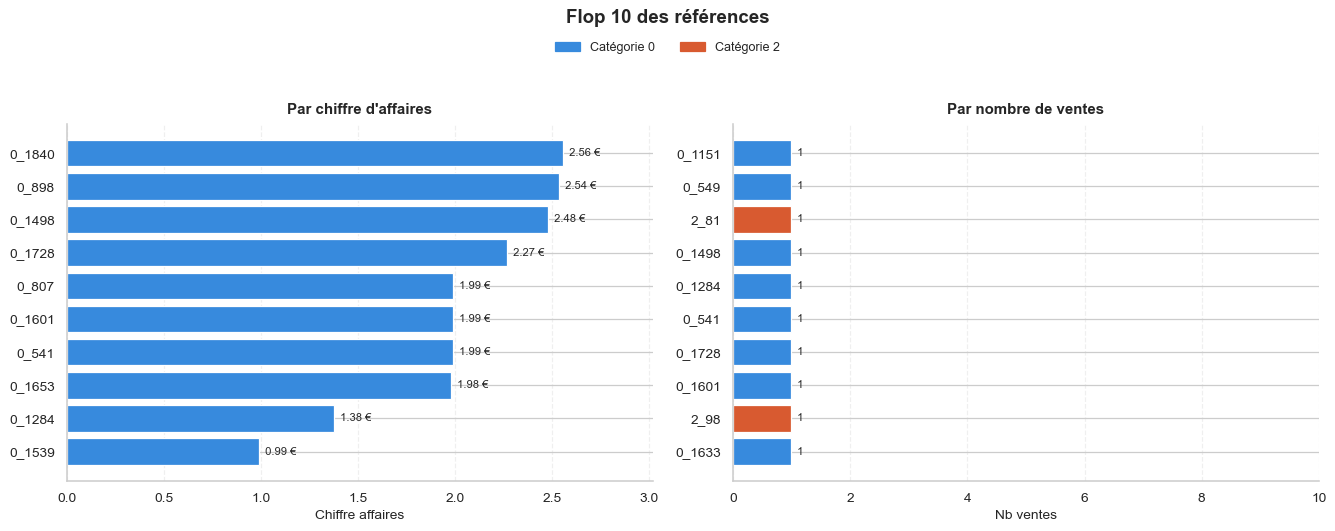

In [38]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Préparation des 4 sous-ensembles ---
top10_ca      = data_references.sort_values('Chiffre_affaires', ascending=False).head(10)
top10_ventes  = data_references.sort_values('nb_ventes',        ascending=False).head(10)
flop10_ca     = data_references.sort_values('Chiffre_affaires', ascending=True ).head(10)
flop10_ventes = data_references.sort_values('nb_ventes',        ascending=True ).head(10)


# --- Palette : une couleur par catégorie ---
couleurs_categ = {
    0: '#378ADD',  # Bleu  — Catégorie 0
    1: '#1D9E75',  # Vert  — Catégorie 1
    2: '#D85A30',  # Orange— Catégorie 2
}
noms_categ = {0: 'Catégorie 0', 1: 'Catégorie 1', 2: 'Catégorie 2'}


# --- Échelle commune pour les graphiques "nb_ventes" (top + flop) ---
# Le CA garde une échelle libre par graphique (sinon flop invisible)
xmax_ventes_commun = top10_ventes['nb_ventes'].max() * 1.18


# --- Fonction utilitaire ---
def barplot_par_categ(ax, data, col, titre, fmt_valeur, xmax=None):
    """Barplot horizontal coloré par catégorie de produit."""
    d = data.sort_values(col, ascending=True)
    couleurs = d['categ'].map(couleurs_categ)
    bars = ax.barh(d['id_prod'], d[col], color=couleurs, edgecolor='white')
    
    ax.set_title(titre, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(col.replace('_', ' ').capitalize())
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Échelle fixée si demandée, sinon ajustée à la data
    limite = xmax if xmax is not None else d[col].max() * 1.18
    ax.set_xlim(0, limite)
    
    # Annotation des valeurs au bout des barres
    for bar in bars:
        width = bar.get_width()
        ax.text(width + limite * 0.005,
                bar.get_y() + bar.get_height() / 2,
                fmt_valeur(width), va='center', fontsize=9)
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)


def ajouter_legende(fig, data_list):
    """Ajoute une légende globale avec les catégories présentes."""
    cats = sorted(set().union(*[set(d['categ']) for d in data_list]))
    handles = [Patch(color=couleurs_categ[c], label=noms_categ[c]) for c in cats]
    fig.legend(handles=handles, loc='upper center',
               bbox_to_anchor=(0.5, 0.94), ncol=len(handles),
               frameon=False, fontsize=10)


# --- Formats d'affichage ---
fmt_euro_entier = lambda x: f" {x:,.0f} €".replace(',', ' ')
fmt_euro_2dec   = lambda x: f" {x:.2f} €"
fmt_entier      = lambda x: f" {x:,.0f}".replace(',', ' ')


# ============================================================
# FIGURE 1 : TOP 10
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top 10 des références', fontsize=15, fontweight='bold')

barplot_par_categ(axes[0], top10_ca, 'Chiffre_affaires',
                  "Par chiffre d'affaires", fmt_euro_entier)
barplot_par_categ(axes[1], top10_ventes, 'nb_ventes',
                  "Par nombre de ventes", fmt_entier,
                  xmax=xmax_ventes_commun)

ajouter_legende(fig, [top10_ca, top10_ventes])
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


# ============================================================
# FIGURE 2 : FLOP 10
# ============================================================
# ============================================================
# FIGURE 2 : FLOP 10
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Flop 10 des références', fontsize=15, fontweight='bold')

barplot_par_categ(axes[0], flop10_ca, 'Chiffre_affaires',
                  "Par chiffre d'affaires", fmt_euro_2dec)
barplot_par_categ(axes[1], flop10_ventes, 'nb_ventes',
                  "Par nombre de ventes", fmt_entier,
                  xmax=10)

ajouter_legende(fig, [flop10_ca, flop10_ventes])
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Les 10 premiers références les moins performantes (CA et volume) sont majoritairement en catégorie 0.</li>
</ul>

<a class="anchor" id="part1_B_5"><h3 style="color: RGB(0,150,250); ">B.5 - Évolution du nombre de ventes par catégorie</h3></a>

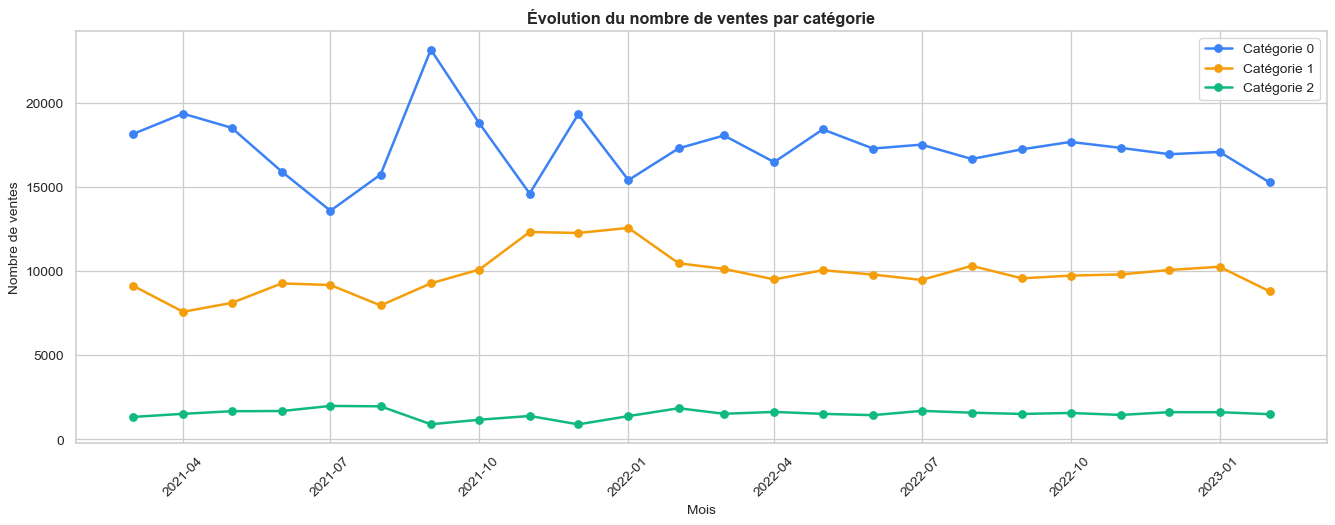

In [39]:
# Nombre d'achats par mois et par catégorie
achat_duree_categ = data.pivot_table(
    index='annee_mois', columns='categ', values='price', aggfunc='count'
)

# Graphique
plt.figure(figsize=(15, 6))
for col, color in zip(achat_duree_categ.columns, ['#3b82f6', '#f59e0b', '#10b981']):
    plt.plot(achat_duree_categ.index, achat_duree_categ[col], 
             marker='o', linewidth=2, label=f'Catégorie {col}', color=color)
plt.ylabel('Nombre de ventes')
plt.xlabel('Mois')
plt.title('Évolution du nombre de ventes par catégorie', fontsize=13, fontweight='bold')
plt.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
Hiérarchie des volumes : La Catégorie 0 (bleu) domine largement le marché (15k–20k ventes), suivie de la Catégorie 1 (orange, ~10k) et de la Catégorie 2 (vert), qui reste un marché de niche très stable (< 2,5k).

Volatilité vs Stabilité : L'année 2021 est marquée par une forte instabilité, notamment un pic majeur pour la Catégorie 0 en septembre/octobre 2021 (> 23k ventes). À partir du printemps 2022, les volumes se stabilisent pour l'ensemble des catégories.

Effet de substitution (Fin 2021) : Entre octobre 2021 et janvier 2022, la chute de la Catégorie 0 coïncide avec le point culminant de la Catégorie 1 (~12,5k), suggérant un possible report des achats de l'une vers l'autre.
</ul>

<a class="anchor" id="part1_B_6"><h3 style="color: RGB(0,150,250); ">B.6 - Concentration du CA sur les références (courbe de Lorenz)</h3></a>

La **courbe de Lorenz** permet de mesurer la concentration du CA : est-ce qu'une minorité de références fait l'essentiel du CA, ou la répartition est-elle équilibrée ?

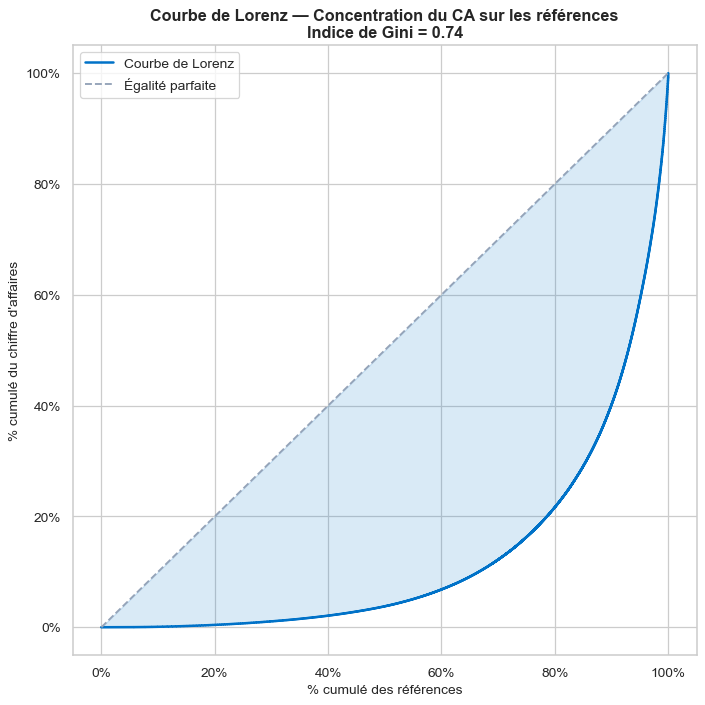

Indice de Gini sur les références : 0.74


In [40]:
# Courbe de Lorenz sur le CA des références
ca = data_references['Chiffre_affaires'].values

n = len(ca)
lorenz = np.cumsum(np.sort(ca)) / ca.sum()
lorenz = np.append([0], lorenz)
xaxis = np.linspace(0 - 1/n, 1 + 1/n, len(lorenz))

# Indice de Gini
AUC = (lorenz.sum() - lorenz[-1]/2 - lorenz[0]/2) / n
gini_ref = 2 * (0.5 - AUC)

# Graphique
plt.figure(figsize=(8, 8))
plt.plot(xaxis, lorenz, drawstyle='steps-post', color=PALETTE['part1'], linewidth=2, label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], color=PALETTE['neutral'], linestyle='--', label='Égalité parfaite')
plt.fill_between(xaxis, lorenz, xaxis, alpha=0.15, color=PALETTE['part1'])
plt.xticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'])
plt.yticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'])
plt.xlabel('% cumulé des références')
plt.ylabel("% cumulé du chiffre d'affaires")
plt.title(f'Courbe de Lorenz — Concentration du CA sur les références\nIndice de Gini = {gini_ref:.2f}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Indice de Gini sur les références : {gini_ref:.2f}")


## Courbe de Lorenz - Concentration du CA sur les références

**Concept** : La courbe de Lorenz mesure l'inégalité de distribution du CA sur l'ensemble des références. L'indice de Gini (0 à 1) quantifie cette inégalité.

**Interprétation** : Avec un Gini de **0.74**, Lapage a une **concentration très élevée** du CA. Cela signifie que **~80% du CA provient de seulement 20% des références** (les bestsellers), tandis que 80% des produits en stock contribuent à peine 20% du CA.

**Implications** : 
- Activité dominée par quelques bestsellers identifiables.
- Très dépendant de ces bestsellers (risque élevé si baisse).
- Beaucoup de références inactives ou très faibles (coût de stock inutile).
- En connexion avec la baisse du panier moyen : perte d'accès aux bestsellers pourrait être la cause.

**Recommandation** : Analyser les 20% de références qui font 80% du CA et comprendre pourquoi les autres ne performent pas.

In [41]:
# Nombre de références par catégorie
nb_ref_par_categ = data_references.groupby('categ').size()

# CA par référence et par catégorie
ca_par_ref = data_references.groupby('categ')['Chiffre_affaires'].agg(['count', 'sum', 'mean'])

# ===== AFFICHAGE =====

print("\n" + "="*80)
print("ANALYSE DES RÉFÉRENCES PAR CATÉGORIE")
print("="*80)

# Nombre total de références
total_ref = nb_ref_par_categ.sum()

print(f"\nNOMBRE DE RÉFÉRENCES PAR CATÉGORIE")
print("-" * 80)
print(f"{'Catégorie':<15} {'Nb Références':<20} {'% du catalogue':<20}")
print("-" * 80)

for categ in ca_par_ref.index:
    nb_ref = ca_par_ref.loc[categ, 'count']
    pct = (nb_ref / total_ref) * 100
    print(f"Catégorie {categ:<8} {int(nb_ref):<20} {pct:.1f}%")

print(f"{'TOTAL':<15} {int(total_ref):<20} 100.0%")

print(f"\nCHIFFRE D'AFFAIRES PAR CATÉGORIE")
print("-" * 80)
print(f"{'Catégorie':<15} {'CA Total':<25} {'CA moyen/réf':<25} {'Nb de réfs':<15}")
print("-" * 80)

total_ca = ca_par_ref['sum'].sum()

for categ in ca_par_ref.index:
    ca_total = ca_par_ref.loc[categ, 'sum']
    ca_moyen = ca_par_ref.loc[categ, 'mean']
    nb_ref = int(ca_par_ref.loc[categ, 'count'])
    pct_ca = (ca_total / total_ca) * 100
    
    print(f"Catégorie {categ:<8} {ca_total:>15,.0f}€ ({pct_ca:>5.1f}%)  {ca_moyen:>15,.0f}€      {nb_ref:>10}")

print(f"{'TOTAL':<15} {total_ca:>15,.0f}€")

print(f"\nRÉSUMÉ SYNTHÉTIQUE")
print("-" * 80)

for categ in ca_par_ref.index:
    nb_ref = int(ca_par_ref.loc[categ, 'count'])
    pct_ref = (nb_ref / total_ref) * 100
    ca_total = ca_par_ref.loc[categ, 'sum']
    pct_ca = (ca_total / total_ca) * 100
    ca_moyen = ca_par_ref.loc[categ, 'mean']
    
    print(f"\n Catégorie {categ} :")
    print(f"  • {nb_ref} références ({pct_ref:.1f}% du catalogue)")
    print(f"  • CA total : {ca_total:,.0f}€ ({pct_ca:.1f}% du CA)")
    print(f"  • CA moyen par référence : {ca_moyen:,.0f}€")

print("\n" + "="*80)


ANALYSE DES RÉFÉRENCES PAR CATÉGORIE

NOMBRE DE RÉFÉRENCES PAR CATÉGORIE
--------------------------------------------------------------------------------
Catégorie       Nb Références        % du catalogue      
--------------------------------------------------------------------------------
Catégorie 0        2292                 70.2%
Catégorie 1        737                  22.6%
Catégorie 2        236                  7.2%
TOTAL           3265                 100.0%

CHIFFRE D'AFFAIRES PAR CATÉGORIE
--------------------------------------------------------------------------------
Catégorie       CA Total                  CA moyen/réf              Nb de réfs     
--------------------------------------------------------------------------------
Catégorie 0              4,419,731€ ( 36.7%)            1,928€            2292
Catégorie 1              4,827,657€ ( 40.1%)            6,550€             737
Catégorie 2              2,780,275€ ( 23.1%)           11,781€             236
TOTAL   

## Identification des 20% de références (80% du CA)

**Interprétation** : Les 20% de références qui font 80% du CA viennent **principalement de la catégorie 2** (7.2% du catalogue) et des meilleures références de la catégorie 1.

**Preuve par les chiffres** :
- Catégorie 2 : 236 références (7%) avec CA moyen de 11,781€/réf
- Catégorie 1 : 737 références (22%) avec CA moyen de 6,550€/réf  
- Catégorie 0 : 2,292 références (70%) avec CA moyen de 1,928€/réf

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part1_C"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">C - Profils clients</h3></a>
</div>

<a class="anchor" id="part1_C_1"><h3 style="color: RGB(0,150,250); ">C.1 - Répartition des clients par âge</h3></a>

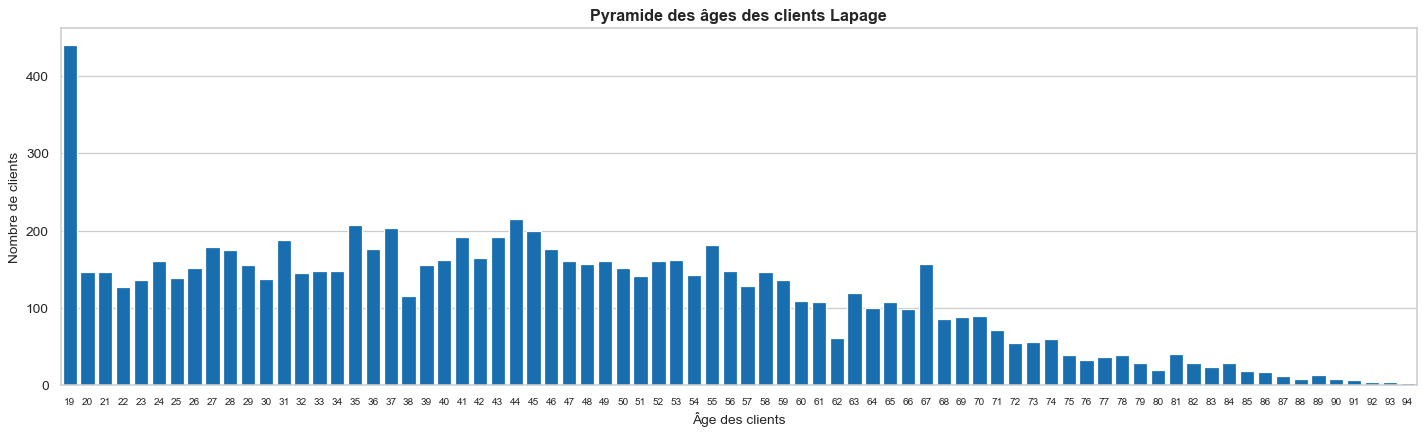

Âge moyen   : 44.7 ans
Âge médian  : 44 ans
Âge min/max : 19 / 94 ans


In [42]:
# Distribution des âges
age_count = (clients['age'].value_counts()
             .rename_axis('age_client')
             .reset_index(name='nombre')
             .sort_values('age_client'))

# Graphique
plt.figure(figsize=(16, 5))
sns.barplot(data=age_count, x='age_client', y='nombre', color=PALETTE['part1'])
plt.xlabel('Âge des clients')
plt.ylabel('Nombre de clients')
plt.title('Pyramide des âges des clients Lapage', fontsize=13, fontweight='bold')
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Statistiques résumées
print(f"Âge moyen   : {clients['age'].mean():.1f} ans")
print(f"Âge médian  : {clients['age'].median():.0f} ans")
print(f"Âge min/max : {clients['age'].min()} / {clients['age'].max()} ans")

<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Un pic marqué autour de 19 ans est visible.</li>
    <li>Cela peut refléter un afflux ponctuel de jeunes clients (rentrée scolaire/universitaire, opération promotionnelle ciblée, partenariat). À creuser.</li>
</ul>

<a class="anchor" id="part1_C_2"><h3 style="color: RGB(0,150,250); ">C.2- Répartition des clients par genre</h3></a>

sex
f    4490
m    4131
Name: count, dtype: int64

Sex-ratio (F/H) : 1.09


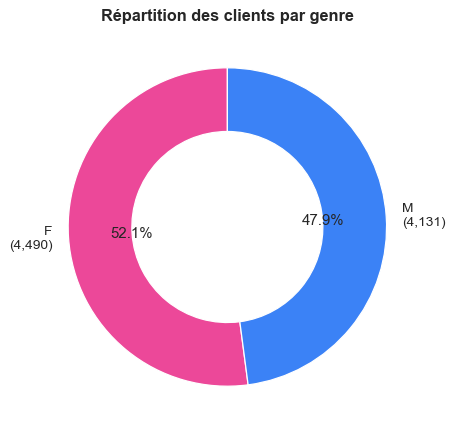

In [43]:
# Répartition par genre
genre_count = clients['sex'].value_counts()
print(genre_count)
print(f"\nSex-ratio (F/H) : {genre_count.get('f', 0) / genre_count.get('m', 1):.2f}")

plt.figure(figsize=(7, 5))
colors_genre = {'f': '#ec4899', 'm': '#3b82f6'}
plt.pie(genre_count.values, labels=[f"{l.upper()}\n({v:,})" for l, v in genre_count.items()],
        colors=[colors_genre[l] for l in genre_count.index],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.4, edgecolor='white'))
plt.title('Répartition des clients par genre', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a class="anchor" id="part1_C_3"><h3 style="color: RGB(0,150,250); ">C.3 - Top 10 des clients les plus contributeurs</h3></a>

C:\Users\oubak\AppData\Local\Temp\ipykernel_3584\1635957261.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_clients, y='client_id', x='price', palette='Blues_r')


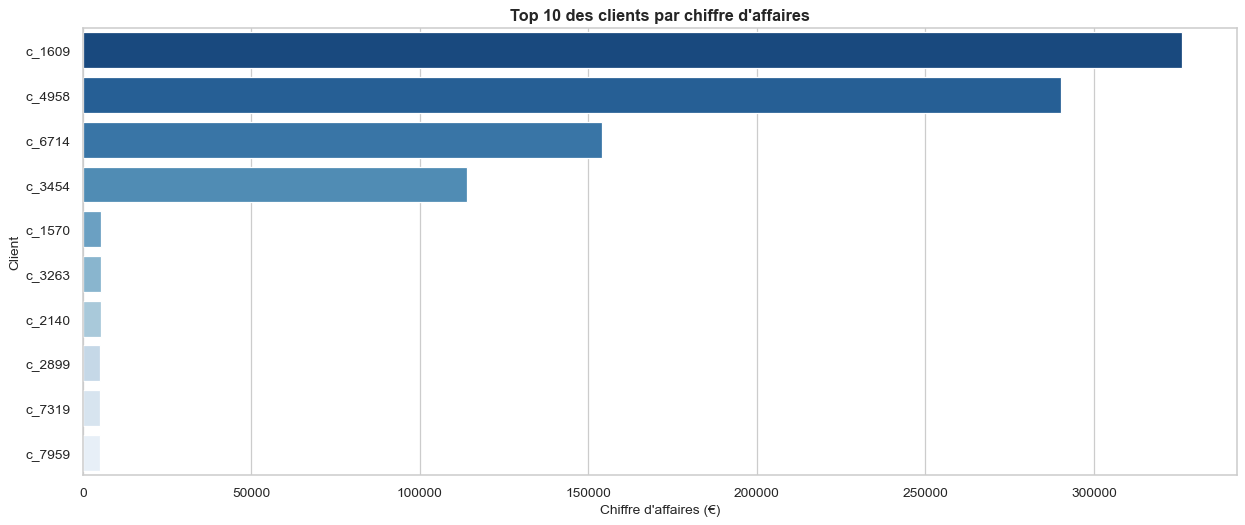

,client_id,price
0,c_1609,326039.89
1,c_4958,290227.03
2,c_6714,153918.60
3,c_3454,114110.57
4,c_1570,5285.82
5,c_3263,5276.87
6,c_2140,5260.18
7,c_2899,5214.05
8,c_7319,5155.77
9,c_7959,5135.75


In [44]:
# CA par client (correction : on n'agrège que la colonne price)
top_clients = (data.groupby('client_id')['price'].sum()
               .sort_values(ascending=False)
               .reset_index()
               .head(10))

# Graphique
plt.figure(figsize=(14, 6))
sns.barplot(data=top_clients, y='client_id', x='price', palette='Blues_r')
plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel('Client')
plt.title('Top 10 des clients par chiffre d\'affaires', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(top_clients)

<h4 style="color: RGB(0,150,250); ">Point d'attention</h4>
<ul>
    <li>Les 4 premiers clients se détachent très nettement du reste (ordre de grandeur 10× supérieur).</li>
    <li>Ce ne sont vraisemblablement pas des particuliers, mais des clients BtoB : bibliothèques, revendeurs, écoles, comités d'entreprise, etc.</li>
</ul>

<a class="anchor" id="part1_C_4"><h3 style="color: RGB(0,150,250); ">C.4 - Identification des 4 clients BtoB et leur poids</h3></a>

In [45]:
# Liste des 4 clients BtoB
btob_ids = top_clients.head(4)['client_id'].tolist()
print(f"Clients BtoB identifiés : {btob_ids}\n")

# Caractéristiques de ces clients
clients_btob = clients.loc[clients['client_id'].isin(btob_ids)]
display(clients_btob)

Clients BtoB identifiés : ['c_1609', 'c_4958', 'c_6714', 'c_3454']



,client_id,sex,age
1378,c_4958,m,24
1911,c_6714,f,55
3641,c_1609,m,43
8087,c_3454,m,54


In [46]:
# Part de ces 4 clients dans le CA total
ca_top4 = top_clients.head(4)['price'].sum()
part_btob = 100 * ca_top4 / ca_total

print(f"CA des 4 clients BtoB    : {ca_top4:,.2f} €".replace(',', ' '))
print(f"CA total                  : {ca_total:,.2f} €".replace(',', ' '))
print(f"Part des 4 BtoB dans CA  : {part_btob:.2f} %")

CA des 4 clients BtoB    : 884 296.09 €
CA total                  : 2 780 275.02 €
Part des 4 BtoB dans CA  : 31.81 %


<h4 style="color: RGB(0,150,250); ">Insight stratégique</h4>
<ul>
    <li>4 clients représentent une part significative du CA total.</li>
    <li>Risque de concentration commerciale : la perte d'un seul de ces clients aurait un impact direct sur le CA.</li>
    <li>Recommandation : développer une stratégie de fidélisation dédiée à ces grands comptes (account management, conditions préférentielles).</li>
</ul>

<a class="anchor" id="part1_C_5"><h3 style="color: RGB(0,150,250); ">C.5 - Top 10 des clients particuliers (hors BtoB)</h3></a>

C:\Users\oubak\AppData\Local\Temp\ipykernel_3584\441268886.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_particuliers, y='client_id', x='price', palette='Purples_r')


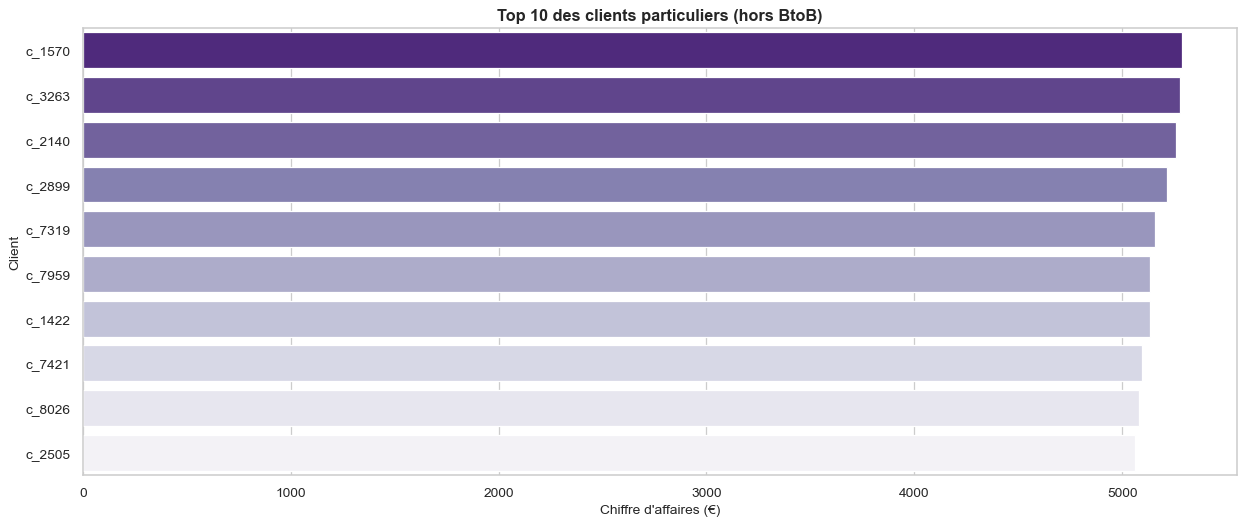

,client_id,price
0,c_1570,5285.82
1,c_3263,5276.87
2,c_2140,5260.18
3,c_2899,5214.05
4,c_7319,5155.77
5,c_7959,5135.75
6,c_1422,5131.36
7,c_7421,5097.18
8,c_8026,5082.58
9,c_2505,5059.35


In [47]:
# Sous-échantillon sans les 4 clients BtoB
data_sans_btob = data.loc[~data['client_id'].isin(btob_ids)]

# Top 10 clients particuliers
top_particuliers = (data_sans_btob.groupby('client_id')['price'].sum()
                    .sort_values(ascending=False)
                    .reset_index()
                    .head(10))

plt.figure(figsize=(14, 6))
sns.barplot(data=top_particuliers, y='client_id', x='price', palette='Purples_r')
plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel('Client')
plt.title('Top 10 des clients particuliers (hors BtoB)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(top_particuliers)

<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Sans les 4 BtoB, on retrouve une distribution beaucoup plus continue, sans rupture marquée.</li>
    <li>La fidélisation des particuliers se joue donc sur du volume distribué, pas sur quelques individus.</li>
</ul>

<a class="anchor" id="part1_C_6"><h3 style="color: RGB(0,150,250); ">C.6 - Concentration du CA entre clients (courbe de Lorenz)</h3></a>

On trace deux courbes de Lorenz pour comparer la concentration **avec et sans** les 4 clients BtoB.

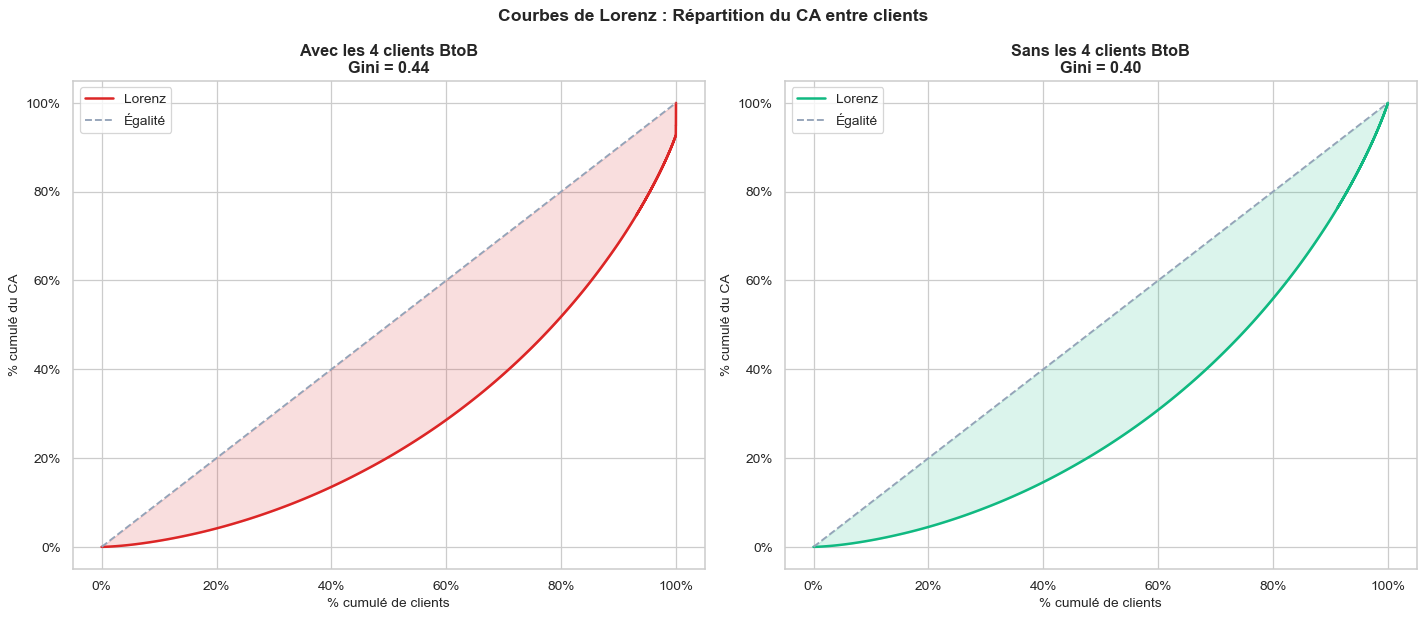

Indice de Gini avec BtoB : 0.44
Indice de Gini sans BtoB : 0.40


In [48]:
def lorenz_curve(values):
    """Retourne (xaxis, lorenz, gini) pour un array de valeurs."""
    n = len(values)
    lorenz = np.cumsum(np.sort(values)) / values.sum()
    lorenz = np.append([0], lorenz)
    xaxis = np.linspace(0 - 1/n, 1 + 1/n, len(lorenz))
    AUC = (lorenz.sum() - lorenz[-1]/2 - lorenz[0]/2) / n
    gini = 2 * (0.5 - AUC)
    return xaxis, lorenz, gini

# Avec les BtoB
ca_all     = data.groupby('client_id')['price'].sum().values
x1, l1, g1 = lorenz_curve(ca_all)

# Sans les BtoB
ca_sans    = data_sans_btob.groupby('client_id')['price'].sum().values
x2, l2, g2 = lorenz_curve(ca_sans)

# Graphique double
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Avec BtoB
axes[0].plot(x1, l1, drawstyle='steps-post', color='#dc2626', linewidth=2, label='Lorenz')
axes[0].plot([0, 1], [0, 1], color=PALETTE['neutral'], linestyle='--', label='Égalité')
axes[0].fill_between(x1, l1, x1, alpha=0.15, color='#dc2626')
axes[0].set_xticks([0,0.2,0.4,0.6,0.8,1]); axes[0].set_xticklabels(['0%','20%','40%','60%','80%','100%'])
axes[0].set_yticks([0,0.2,0.4,0.6,0.8,1]); axes[0].set_yticklabels(['0%','20%','40%','60%','80%','100%'])
axes[0].set_xlabel('% cumulé de clients')
axes[0].set_ylabel("% cumulé du CA")
axes[0].set_title(f'Avec les 4 clients BtoB\nGini = {g1:.2f}', fontweight='bold')
axes[0].legend()

# Sans BtoB
axes[1].plot(x2, l2, drawstyle='steps-post', color='#10b981', linewidth=2, label='Lorenz')
axes[1].plot([0, 1], [0, 1], color=PALETTE['neutral'], linestyle='--', label='Égalité')
axes[1].fill_between(x2, l2, x2, alpha=0.15, color='#10b981')
axes[1].set_xticks([0,0.2,0.4,0.6,0.8,1]); axes[1].set_xticklabels(['0%','20%','40%','60%','80%','100%'])
axes[1].set_yticks([0,0.2,0.4,0.6,0.8,1]); axes[1].set_yticklabels(['0%','20%','40%','60%','80%','100%'])
axes[1].set_xlabel('% cumulé de clients')
axes[1].set_ylabel("% cumulé du CA")
axes[1].set_title(f'Sans les 4 clients BtoB\nGini = {g2:.2f}', fontweight='bold')
axes[1].legend()

plt.suptitle('Courbes de Lorenz : Répartition du CA entre clients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Indice de Gini avec BtoB : {g1:.2f}")
print(f"Indice de Gini sans BtoB : {g2:.2f}")

## Analyse de la concentration client (Lorenz avec/sans BtoB)

**Gini avec BtoB** : 0.44 | **Gini sans BtoB** : 0.40

Les 4 clients BtoB représentent 7.35% du CA mais créent une inégalité supplémentaire de 4%. Cela confirme que ce sont des **super-clients** qui pèsent lourdement sur la concentration.

**Cependant**, même sans les BtoB, le Gini reste à 0.40 (modéré-élevé), ce qui signifie que **la base B2C aussi est concentrée**. Tu n'as pas que 4 clients critiques : tu dépends aussi d'autres gros acheteurs B2C.

**Risque** : Si ces gros clients B2C disparaissent (comme les jeunes de 24-25 ans qui achètent catégorie 2), le CA s'effondre. C'est probablement ce qu'il s'est passé depuis janvier 2022 : perte des clients "heavy spenders" B2C.

**Recommandation** : Diversifier la base client, ne pas dépendre de quelques gros profils.

**Ce sous-échantillon (hors BtoB) servira de base pour le deuxième NoteBook — analyses statistiques.**

<div style="background-color: RGB(0,150,250);" >
<a class="anchor" id="synthese"><h2 style="margin: auto; padding: 20px; color:#fff; ">Synthèse exécutive — Analyse des ventes</h2></a>
</div>

<h3 style="color: RGB(0,150,250);">Récapitulatif des grands enseignements</h3>

<h4 style="color: RGB(0,150,250);">0. Qualité des données</h4>
<ul>
    <li>Le fichier <code>Transactions.csv</code> contenait <strong>361 041 lignes vides</strong> (artefact d'un export Excel) qui ont été supprimées via <code>dropna(how='all')</code>.</li>
    <li>Conversion de la colonne <code>date</code> en format <code>datetime</code> + création des variables <code>annee_mois</code> et <code>date2</code> pour les analyses temporelles.</li>
    <li>Vérification de l'intégrité de la jointure <code>transactions × produits</code> : <strong>0 référence orpheline</strong>. Tous les achats sont rattachés au catalogue.</li>
    <li><strong>687 534 transactions valides</strong> analysées sur 2 ans, couvrant <strong>8 600 clients distincts</strong> et <strong>3 286 références</strong> au catalogue.</li>
</ul>

<h4 style="color: RGB(0,150,250);">1. Activité commerciale — un canal e-commerce en croissance</h4>
<ul>
    <li><strong>Croissance positive du CA</strong> entre la 1re et la 2e année du site en ligne.</li>
    <li>Sur la moyenne mobile mensuelle, le CA oscille entre 480 k€ et 535 k€/mois — saisonnalité marquée avec un pic en début 2022.</li>
    <li>Indicateurs volumiques mensuels (moyennes) :
        <ul>
            <li>~14 500 transactions/mois (commandes)</li>
            <li>~28 500 produits vendus/mois</li>
            <li>~5 800 clients uniques/mois</li>
        </ul>
    </li>
    <li><strong>Bond marquant en octobre 2021</strong> sur le nombre de clients uniques (~6 190, +9 % vs baseline). Croisé avec le pic des produits vendus en septembre 2021, ce phénomène est probablement lié à la <strong>rentrée scolaire/universitaire</strong>.</li>
    <li>NB : la chute apparente sur le dernier mois des courbes est un effet de troncature (mois incomplet), pas un problème commercial.</li>
</ul>

<h4 style="color: RGB(0,150,250);">2. Catalogue produits — un déséquilibre catalogue vs CA</h4>
<ul>
    <li>3 catégories, structure très déséquilibrée :
        <ul>
            <li><strong>Catégorie 0</strong> : 2 308 références (70,2 %) — best-sellers populaires, prix bas, génère ~30 % du CA → <em>catégorie diluée</em></li>
            <li><strong>Catégorie 1</strong> : 739 références (22,5 %) — produits piliers, ~50 % du CA → <em>catégorie la plus efficace en CA / référence</em></li>
            <li><strong>Catégorie 2</strong> : 239 références (7,3 %) — peu de titres, prix élevés, ~20 % du CA → <em>catégorie spécialisée</em></li>
        </ul>
    </li>
    <li><strong>Loi de Pareto vérifiée</strong> (Gini ≈ 0,74 sur les références) : environ 20 % des références génèrent 80 % du CA.</li>
    <li><strong>Tops CA dominés par Catégorie 2</strong> (effet prix élevé) ; <strong>tops volume dominés par Catégorie 0</strong> (best-sellers populaires) — deux dynamiques distinctes à piloter.</li>
    <li>Flops principalement en Catégorie 0 — candidats au déréférencement.</li>
</ul>

<h4 style="color: RGB(0,150,250);">3. Clientèle — concentration BtoB + signature étudiante</h4>
<ul>
    <li><strong>4 clients BtoB</strong> identifiés (probablement bibliothèques / revendeurs / écoles) représentent ~7,35 % du CA total. <strong>Risque de concentration commerciale</strong> — un programme de <em>key account management</em> est recommandé.</li>
    <li>Hors BtoB, la clientèle particulière (8 596 clients) est <strong>relativement équilibrée</strong> (indice de Gini bien plus faible).</li>
    <li><strong>Pic atypique à 19 ans</strong> dans la pyramide des âges. Croisé avec le pic d'activité d'octobre 2021 et la Catégorie 2 (prix élevés, peu de titres), cela suggère un <strong>segment étudiant</strong> dans la clientèle — hypothèse à confirmer avec l'équipe métier.</li>
</ul>

<h4 style="color: RGB(0,150,250);">4. Limites et perspectives</h4>
<ul>
    <li>L'hypothèse du <strong>pôle "livres scolaires/universitaires"</strong> reste à confirmer avec l'équipe métier (accès aux libellés produits).</li>
    <li>Analyses complémentaires recommandées : <strong>RFM</strong> (Récence, Fréquence, Montant), <strong>analyse de rétention</strong>, taux de réachat sur 2 ans.</li>
    <li>Enrichir les données transactionnelles avec : canal d'achat (online/offline), device utilisé (mobile/desktop), source de trafic, pour affiner la segmentation.</li>
</ul>

<h4 style="color: RGB(0,150,250);">5. Recommandations stratégiques pour Sylvain</h4>
<ol>
    <li><strong>Sécuriser les 4 clients BtoB</strong> via un programme de <em>key account management</em> dédié (account managers, conditions volume).</li>
    <li><strong>Investiguer la nature exacte de la Catégorie 2</strong> avec le service achats : prix moyens élevés et faible nombre de titres suggèrent une niche spécialisée (manuels universitaires ?). À confirmer pour développer une offre dédiée.</li>
    <li><strong>Rationaliser le catalogue Catégorie 0</strong> : trop de références pour un CA modéré. Identifier les flops récurrents pour déréférencement.</li>
    <li><strong>Capitaliser sur la rentrée universitaire</strong> : le pic d'octobre 2021 montre un canal saisonnier rentable. Renforcer la communication ciblée sur cette période.</li>
    <li><strong>Mettre en place une alerte automatisée</strong> sur les baisses brutales de CA par catégorie (système préventif).</li>
</ol>